In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

---
## Data Overview

In [52]:
df = pd.read_csv('../data/car details v4.csv')

In [53]:
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

In [55]:
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Make,2059,33,Maruti Suzuki,440,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,2059,1050,X1 sDrive20d xLine,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,2059.0,NaN,NaN,NaN,1702991.696455,2419880.635434,49000.0,484999.0,825000.0,1925000.0,35000000.0
Year,2059.0,NaN,NaN,NaN,2016.425449,3.363564,1988.0,2014.0,2017.0,2019.0,2022.0
Kilometer,2059.0,NaN,NaN,NaN,54224.714424,57361.721314,0.0,29000.0,50000.0,72000.0,2000000.0
Fuel Type,2059,9,Diesel,1049,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,2059,2,Manual,1133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,2059,77,Mumbai,342,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Color,2059,17,White,802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,2059,6,First,1619,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## Feature Engineering

In [56]:
df['Engine'] = df['Engine'].str.rstrip(' cc').astype(float)

In [57]:
df['Max Power'].value_counts(dropna=False).head(50)

Max Power
89 bhp @ 4000 rpm     90
NaN                   80
82 bhp @ 6000 rpm     62
126 bhp @ 4000 rpm    55
83 bhp @ 6000 rpm     55
74 bhp @ 4000 rpm     50
117 bhp @ 6600 rpm    39
89 bhp @ 6000 rpm     38
81 bhp @ 6000 rpm     37
67 bhp @ 6000 rpm     35
184 bhp @ 4000 rpm    32
192 bhp @ 3800 rpm    29
188 bhp @ 4000 rpm    28
85 bhp @ 6000 rpm     27
99 bhp @ 3600 rpm     24
174 bhp @ 4200 rpm    23
122 bhp @ 6400 rpm    23
87 bhp @ 6000 rpm     23
67 bhp @ 5500 rpm     23
67 bhp @ 6200 rpm     23
174 bhp @ 3400 rpm    22
258 bhp @ 4000 rpm    22
148 bhp @ 3400 rpm    21
120 bhp @ 4000 rpm    21
47 bhp @ 6000 rpm     21
79 bhp @ 6000 rpm     20
177 bhp @ 4000 rpm    19
103 bhp @ 6000 rpm    18
169 bhp @ 3600 rpm    18
121 bhp @ 6300 rpm    17
138 bhp @ 3750 rpm    17
113 bhp @ 4000 rpm    17
141 bhp @ 3500 rpm    16
84 bhp @ 3750 rpm     16
91 bhp @ 6000 rpm     16
118 bhp @ 6000 rpm    16
134 bhp @ 3600 rpm    15
58 bhp @ 6200 rpm     14
118@6600              14
140 bhp @ 3750 

In [58]:
df.loc[
    ~df['Max Power'].str.contains('bhp', na=False),
    'Max Power'
].drop_duplicates()

33            NaN
43       165@5500
80       207@4200
110      118@6600
117       63@5500
135      116@3800
164      152@6000
177       68@6200
189       75@4000
192      102@5600
195      234@3800
204      231@3800
238      171@3600
264       67@6200
276      177@4000
286       80@5200
293       90@4300
295       47@6200
319       95@3600
359       87@6000
360       90@6000
388      120@4000
389      136@5600
433      204@6100
447       59@6200
470      120@5500
491       35@5250
552      122@4000
618       56@5500
628     171 @3600
699      142@4000
740      150@4000
756      170@3700
846      272@6000
848       64@6200
854      218@4000
899      132@6000
922      100@5500
1032     105@3800
1150      68@4000
1205      90@4000
1279      69@4000
1293      67@5500
1549     102@5500
1579     240@4000
1801      58@6000
1936      78@5500
2004     198@4000
Name: Max Power, dtype: object

In [59]:
df[['Max_Power_bhp', 'Max_Power_rpm']] = df['Max Power'].str.extract(r'(\d+\.?\d*)\D*@\D*(\d+)').astype(float)

In [60]:
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,...,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Max_Power_bhp,Max_Power_rpm
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,...,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0,87.0,6000.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,...,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0,74.0,4000.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,...,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0,79.0,6000.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,...,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0,82.0,6000.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,...,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0,148.0,3400.0


In [61]:
df['Max Torque'].value_counts(dropna=False).head(50)

Max Torque
200 Nm @ 1750 rpm         90
NaN                       80
115 Nm @ 4000 rpm         78
114 Nm @ 4000 rpm         66
90 Nm @ 3500 rpm          64
400 Nm @ 1750 rpm         63
380 Nm @ 1750 rpm         59
190 Nm @ 2000 rpm         45
145 Nm @ 4600 rpm         42
350 Nm @ 1750 rpm         39
250 Nm @ 1500 rpm         34
110 Nm @ 4800 rpm         30
400 Nm @ 1600 rpm         29
343 Nm @ 1400 rpm         28
300 Nm @ 1600 rpm         27
320 Nm @ 1750 rpm         26
500 Nm @ 1600 rpm         25
113 Nm @ 4200 rpm         25
130 Nm @ 4000 rpm         23
69 Nm @ 3500 rpm          22
560 Nm @ 1500 rpm         22
260 Nm @ 1900 rpm         22
450 Nm @ 1600 rpm         20
265 Nm @ 1900 rpm         19
430 Nm @ 1750 rpm         19
109 Nm @ 4500 rpm         19
138 Nm @ 4400 rpm         18
220 Nm @ 1500 rpm         18
91 Nm @ 4250 rpm          18
260 Nm @ 1500 rpm         17
158 Nm @ 4200 rpm         16
172 Nm @ 1500 rpm         16
112.7619 Nm @ 4000 rpm    16
154 Nm @ 4850 rpm         15
77 

In [62]:
df.loc[
    ~df['Max Torque'].str.contains('Nm', na=False),
    'Max Torque'
].drop_duplicates()

33            NaN
43       240@3000
80       500@1600
110      146@4600
117       89@3000
135      277@1700
164      215@3600
177       90@3500
189      190@2000
192      200@1400
195      535@1600
204      540@1600
238      343@1400
264       84@3500
276      400@2000
286      111@4000
293      190@3000
295       62@3000
319      220@1400
359      113@4500
360      115@4500
388      250@1500
389      182@4000
433      245@5000
447       77@3500
459      116@4750
470      170@3500
491       48@3000
552      290@1800
618       75@4000
628     343 @1400
699      323@2000
740      327@2600
756      410@2000
846      350@2400
854      480@1750
899      170@4200
900      350@1750
922      137@4200
1032     247@1800
1078     112@4000
1150     160@2000
1205     220@1750
1293      99@2800
1356     320@2000
1549     145@4200
1579     500@1500
1801      77@4500
1821     200@3400
1936     125@2700
2004     456@1400
Name: Max Torque, dtype: object

In [63]:
df[['Max_Torque_Nm', 'Max_Torque_rpm']] = df['Max Torque'].str.extract(r'(\d+\.?\d*)\D*@\D*(\d+)').astype(float)

In [64]:
df.drop(columns=['Max Power', 'Max Torque'], inplace=True)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   float64
 12  Drivetrain          1923 non-null   object 
 13  Length              1995 non-null   float64
 14  Width               1995 non-null   float64
 15  Height              1995 non-null   float64
 16  Seatin

---
## Missing Values

In [66]:
def missing_values_perc(df):
    missing = df.isnull().sum()
    perc = (missing / df.shape[0]) * 100
    return perc[perc > 0].sort_values(ascending=False)

In [67]:
missing_percent = missing_values_perc(df)

In [68]:
missing_percent

Drivetrain            6.605148
Fuel Tank Capacity    5.488101
Max_Power_bhp         4.079650
Max_Power_rpm         4.079650
Engine                3.885381
Max_Torque_rpm        3.885381
Max_Torque_Nm         3.885381
Length                3.108305
Seating Capacity      3.108305
Width                 3.108305
Height                3.108305
dtype: float64

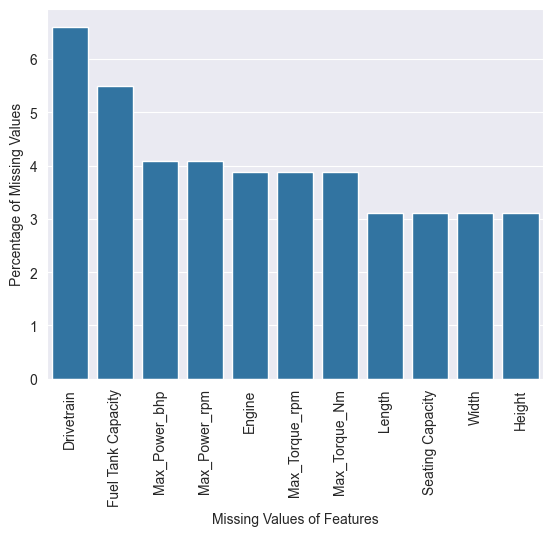

In [69]:
sns.barplot(x=missing_percent.index, y=missing_percent)
plt.xlabel('Missing Values of Features')
plt.ylabel('Percentage of Missing Values')
plt.xticks(rotation=90);

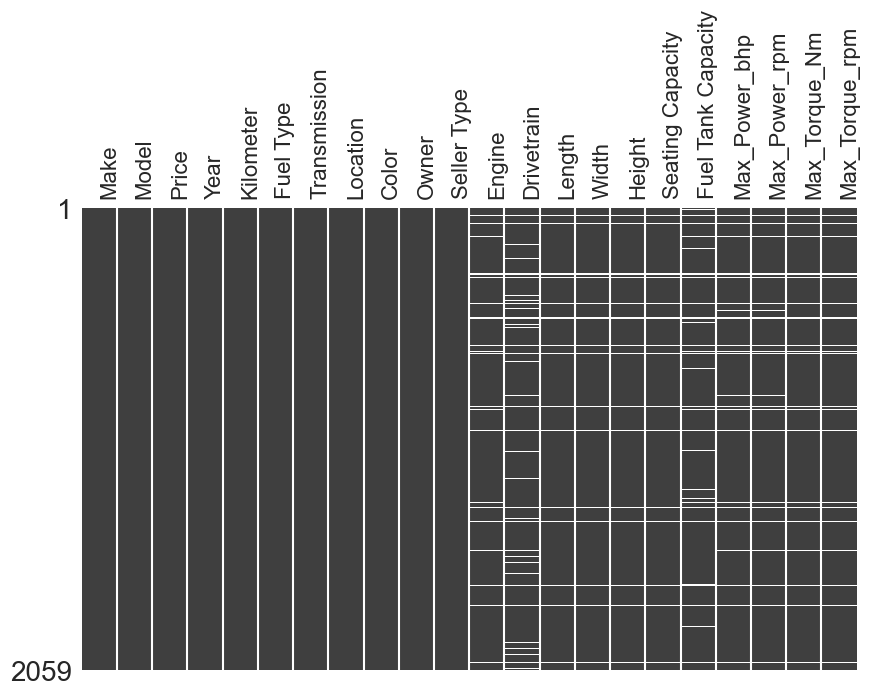

In [70]:
fig, ax = plt.subplots(figsize=(10, 6))
msno.matrix(df, ax=ax, sparkline=False)
plt.xticks(rotation=90);

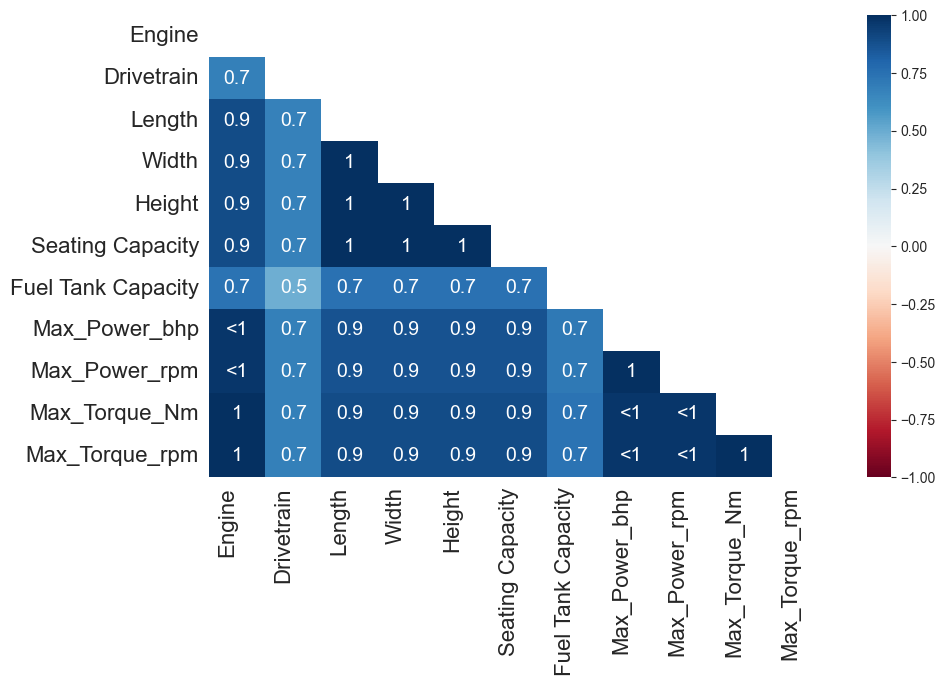

In [71]:
fig, ax = plt.subplots(figsize=(10, 6))
msno.heatmap(df, ax=ax)
plt.xticks(rotation=90);

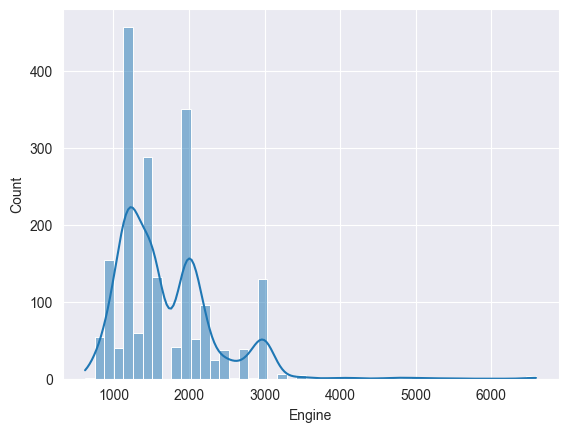

In [72]:
sns.histplot(df['Engine'].dropna(), kde=True)
plt.show()

**During EDA, missing values were identified and analyzed. Missing value imputation was performed in the preprocessing step using SimpleImputer in the training pipeline to avoid data leakage.
We use the median strategy to fill in the numerical features and the Most Frequent strategy to fill in the missing data of the categorical features.**
---
## Numerical Analysis

In [73]:
skewness = df.skew(numeric_only=True).sort_values(ascending=False)

In [74]:
skewness

Kilometer             20.980719
Price                  4.965143
Max_Power_bhp          2.073164
Engine                 1.755060
Seating Capacity       1.468083
Max_Torque_Nm          0.880474
Fuel Tank Capacity     0.853003
Height                 0.837780
Max_Torque_rpm         0.537321
Width                  0.308335
Max_Power_rpm          0.209820
Length                -0.021523
Year                  -0.840685
dtype: float64

<Axes: xlabel='Kilometer', ylabel='Count'>

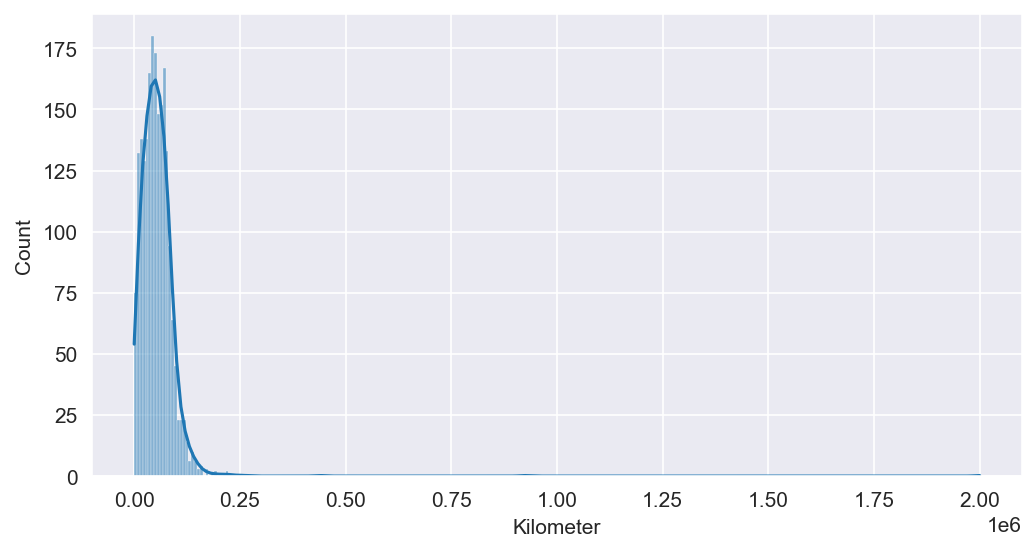

In [75]:
plt.figure(figsize=(8, 4), dpi=150)
sns.histplot(x='Kilometer', data=df, kde=True)

<Axes: xlabel='Price', ylabel='Count'>

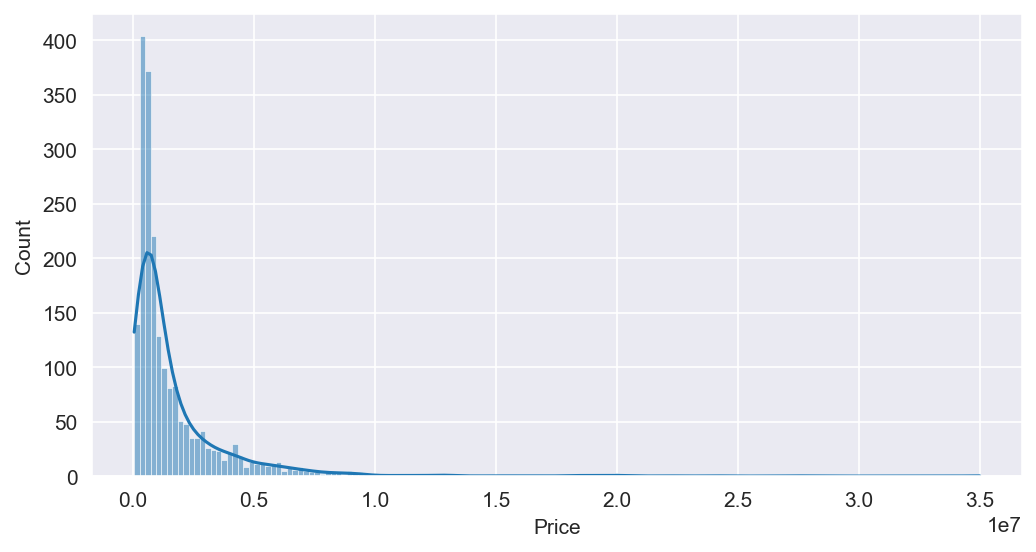

In [76]:
plt.figure(figsize=(8, 4), dpi=150)
sns.histplot(x='Price', data=df, kde=True)

<Axes: xlabel='Max_Power_bhp', ylabel='Count'>

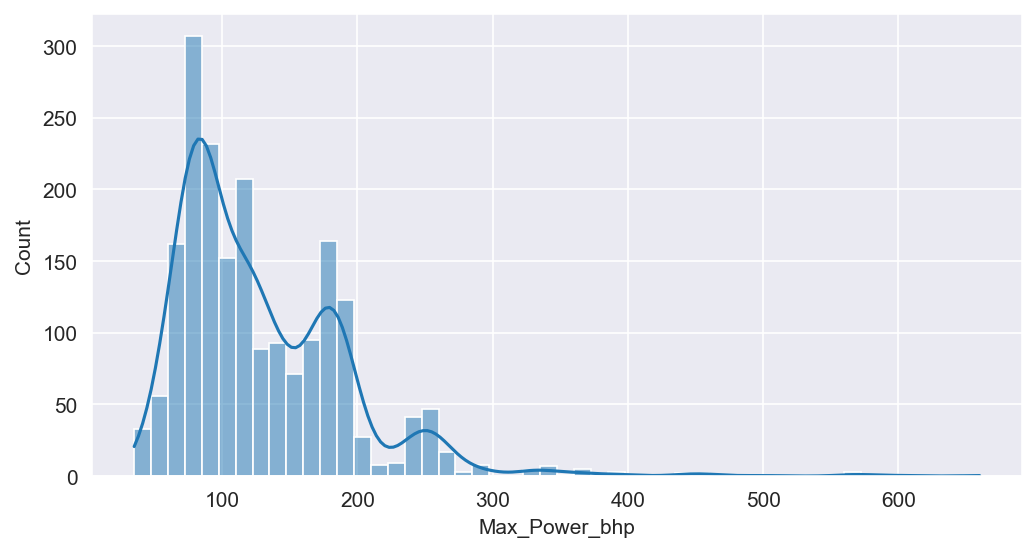

In [77]:
plt.figure(figsize=(8, 4), dpi=150)
sns.histplot(x='Max_Power_bhp', data=df, kde=True, bins=50)

<Axes: xlabel='Max_Torque_Nm', ylabel='Count'>

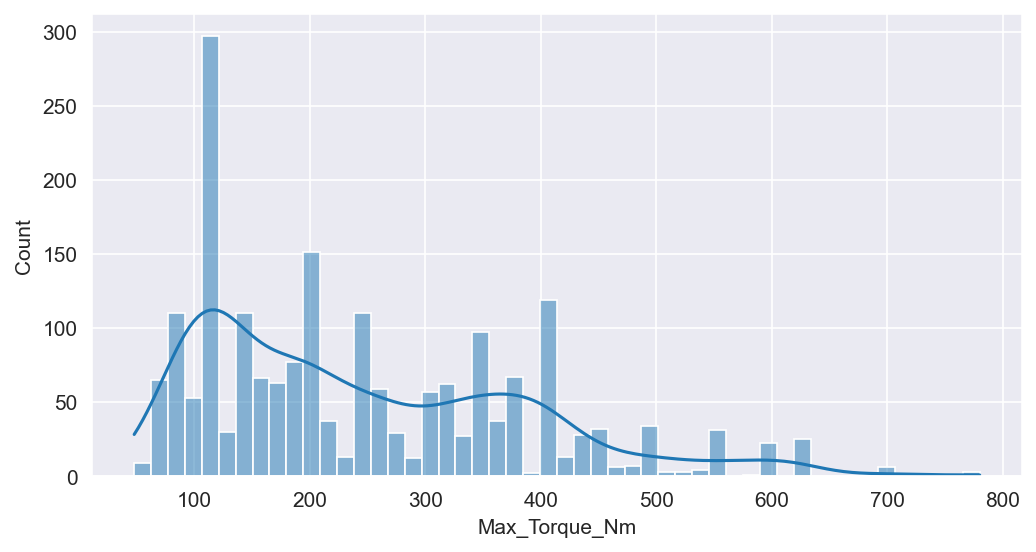

In [78]:
plt.figure(figsize=(8, 4), dpi=150)
sns.histplot(x='Max_Torque_Nm', data=df, kde=True, bins=50)

<Axes: xlabel='Engine', ylabel='Count'>

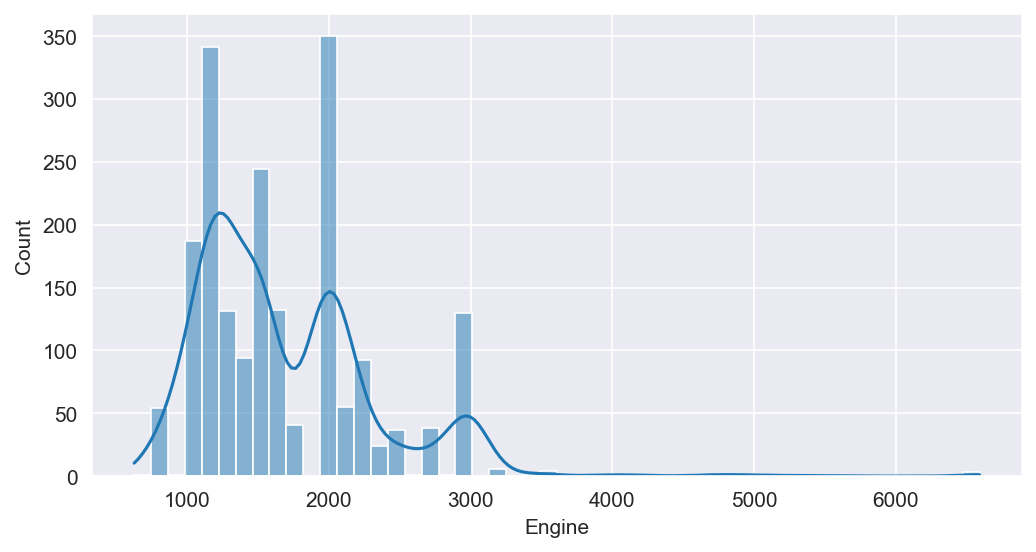

In [79]:
plt.figure(figsize=(8, 4), dpi=150)
sns.histplot(x='Engine', data=df, kde=True, bins=50)

<Axes: xlabel='Max_Power_bhp', ylabel='Price'>

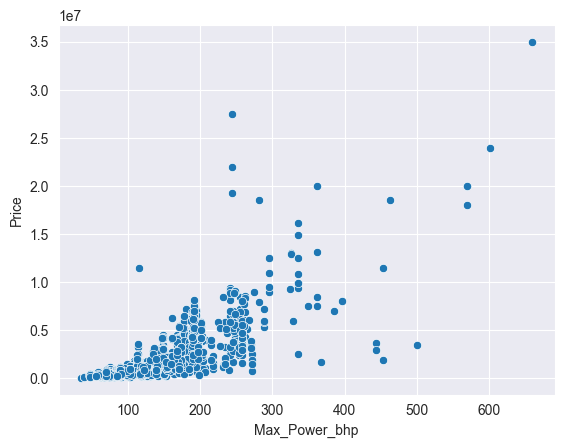

In [80]:
sns.scatterplot(x='Max_Power_bhp', y='Price', data=df)

<Axes: xlabel='Max_Torque_Nm', ylabel='Price'>

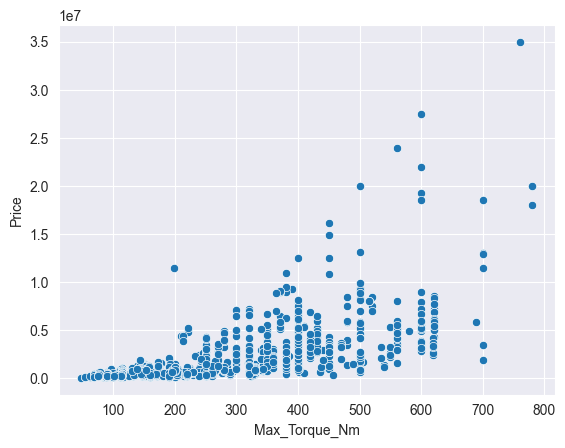

In [81]:
sns.scatterplot(x='Max_Torque_Nm', y='Price', data=df)

<Axes: xlabel='Fuel Tank Capacity', ylabel='Price'>

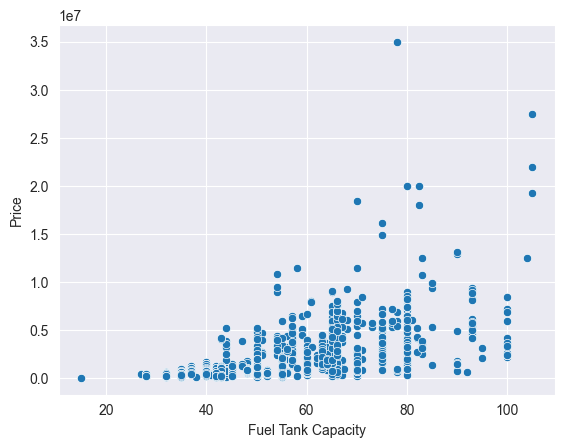

In [82]:
sns.scatterplot(x='Fuel Tank Capacity', y='Price', data=df)

<Axes: xlabel='Width', ylabel='Price'>

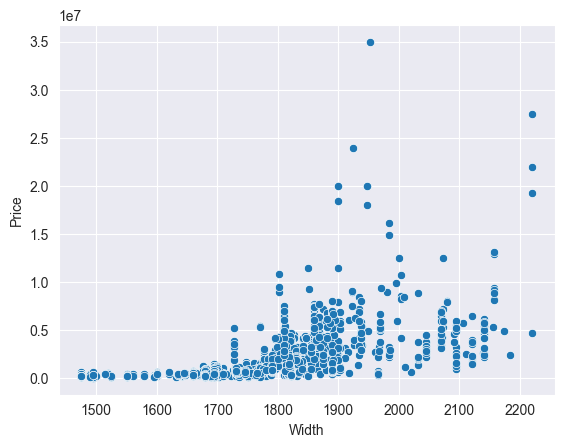

In [83]:
sns.scatterplot(x='Width', y='Price', data=df)

<Axes: xlabel='Length', ylabel='Price'>

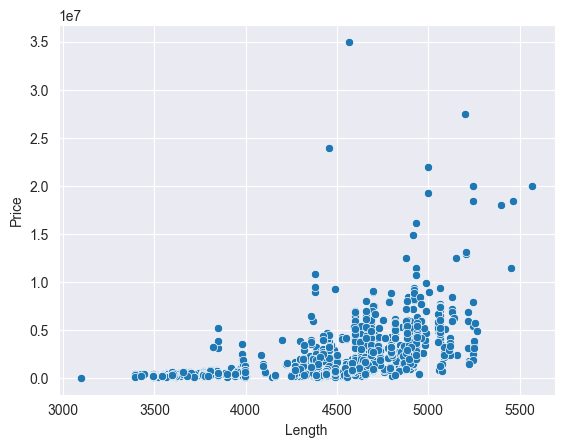

In [84]:
sns.scatterplot(x='Length', y='Price', data=df)

---
## Categorical Analysis

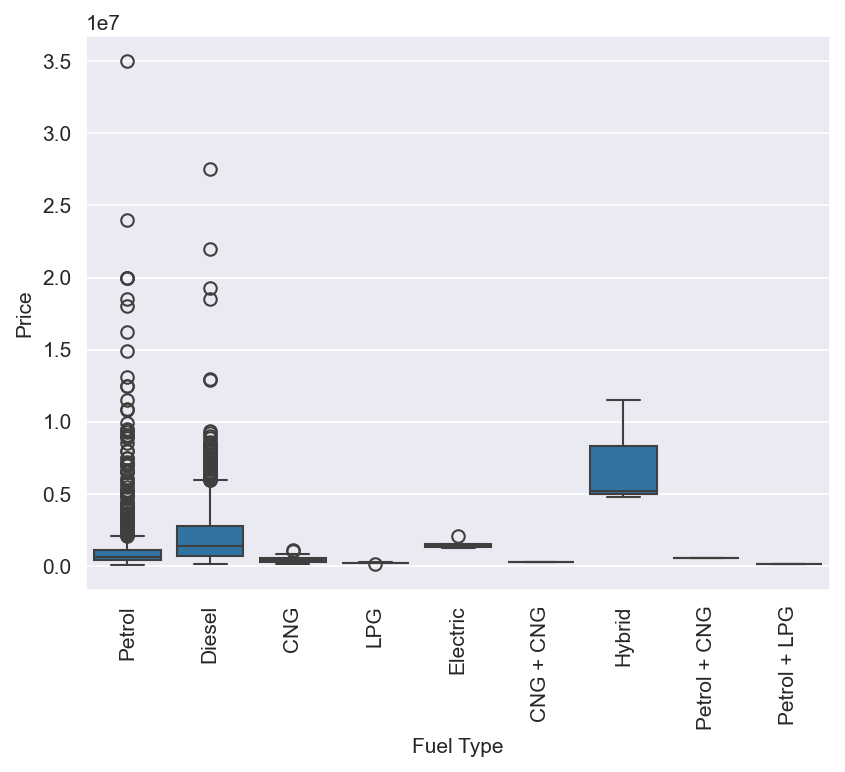

In [85]:
plt.figure(dpi=150)
sns.boxplot(x='Fuel Type', y='Price', data=df)
plt.xticks(rotation=90);

<Axes: xlabel='Transmission', ylabel='Price'>

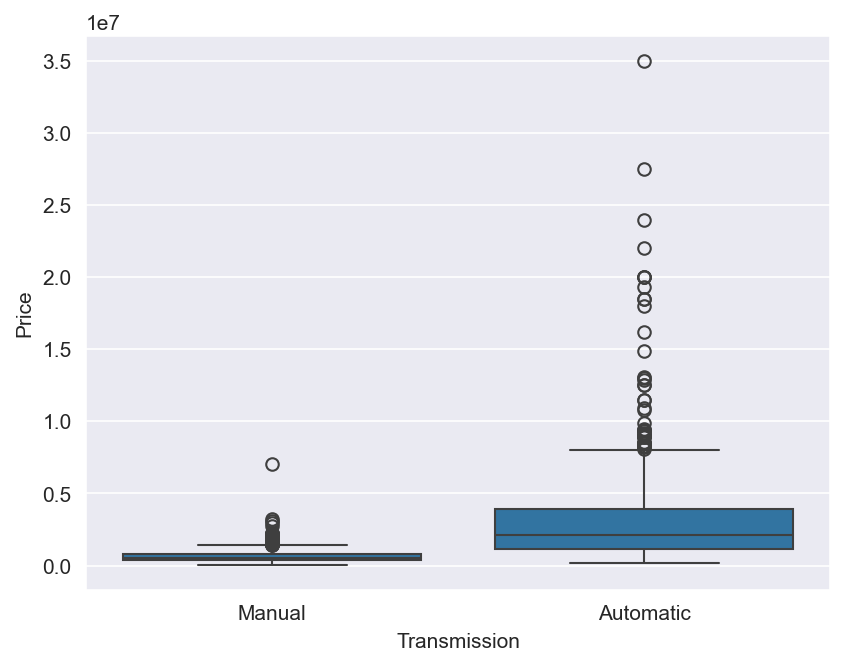

In [86]:
plt.figure(dpi=150)
sns.boxplot(x='Transmission', y='Price', data=df)

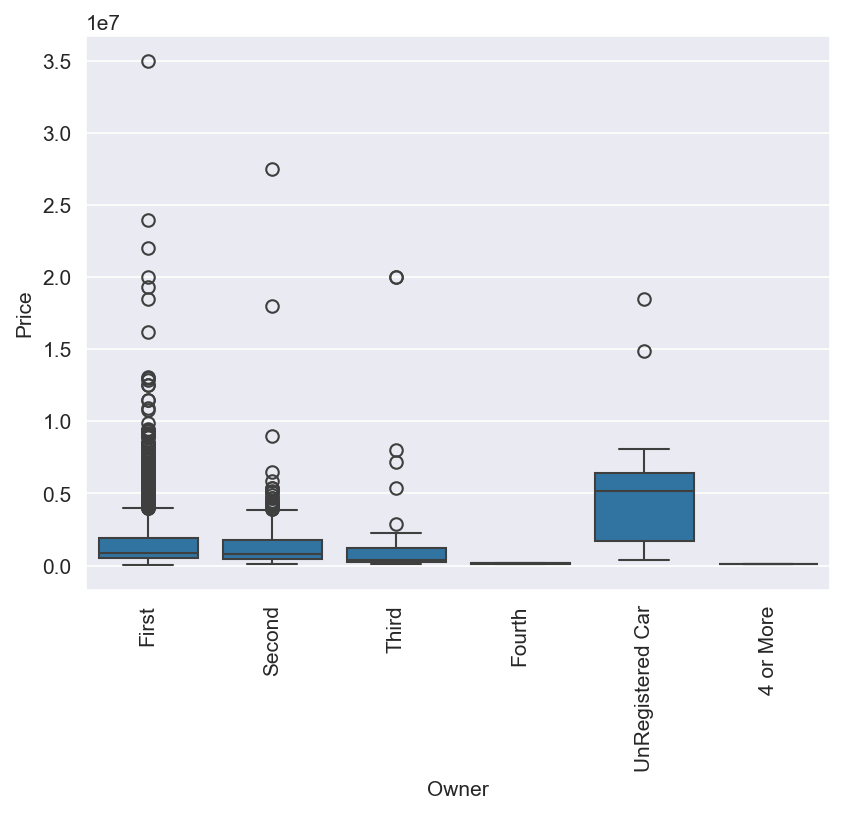

In [87]:
plt.figure(dpi=150)
sns.boxplot(x='Owner', y='Price', data=df)
plt.xticks(rotation=90);

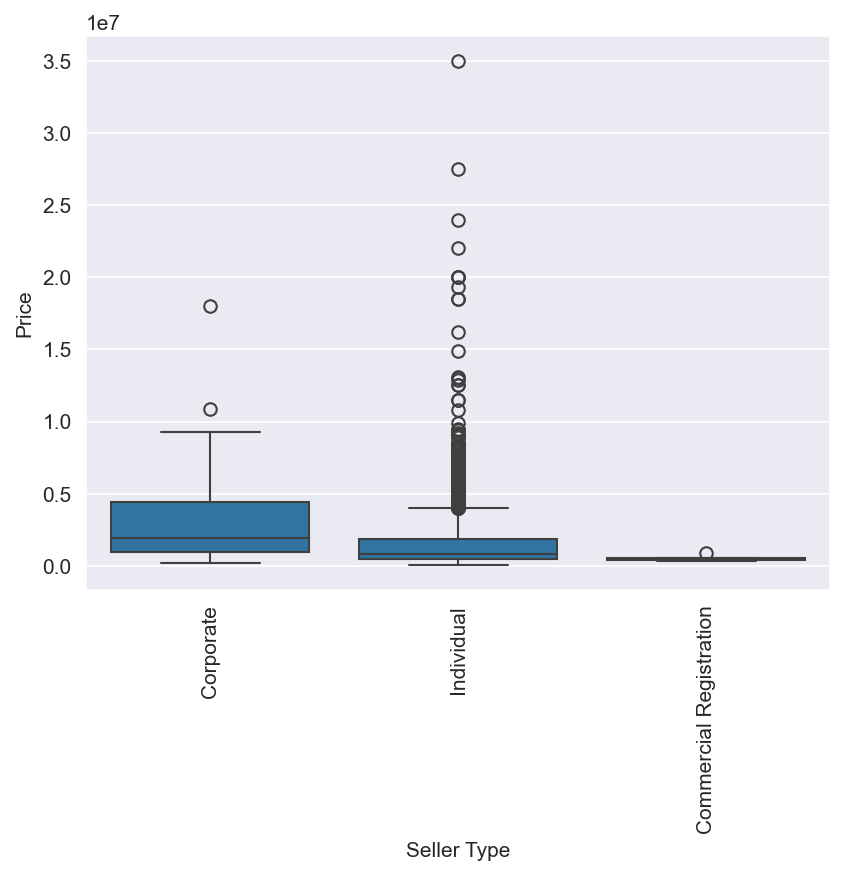

In [88]:
plt.figure(dpi=150)
sns.boxplot(x='Seller Type', y='Price', data=df)
plt.xticks(rotation=90);

<Axes: xlabel='Drivetrain', ylabel='Price'>

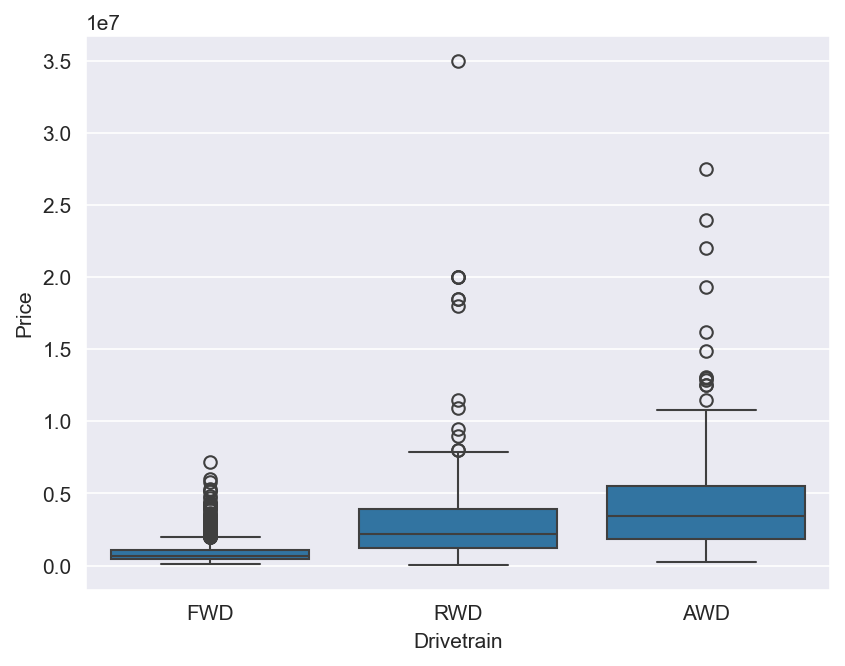

In [89]:
plt.figure(dpi=150)
sns.boxplot(x='Drivetrain', y='Price', data=df)

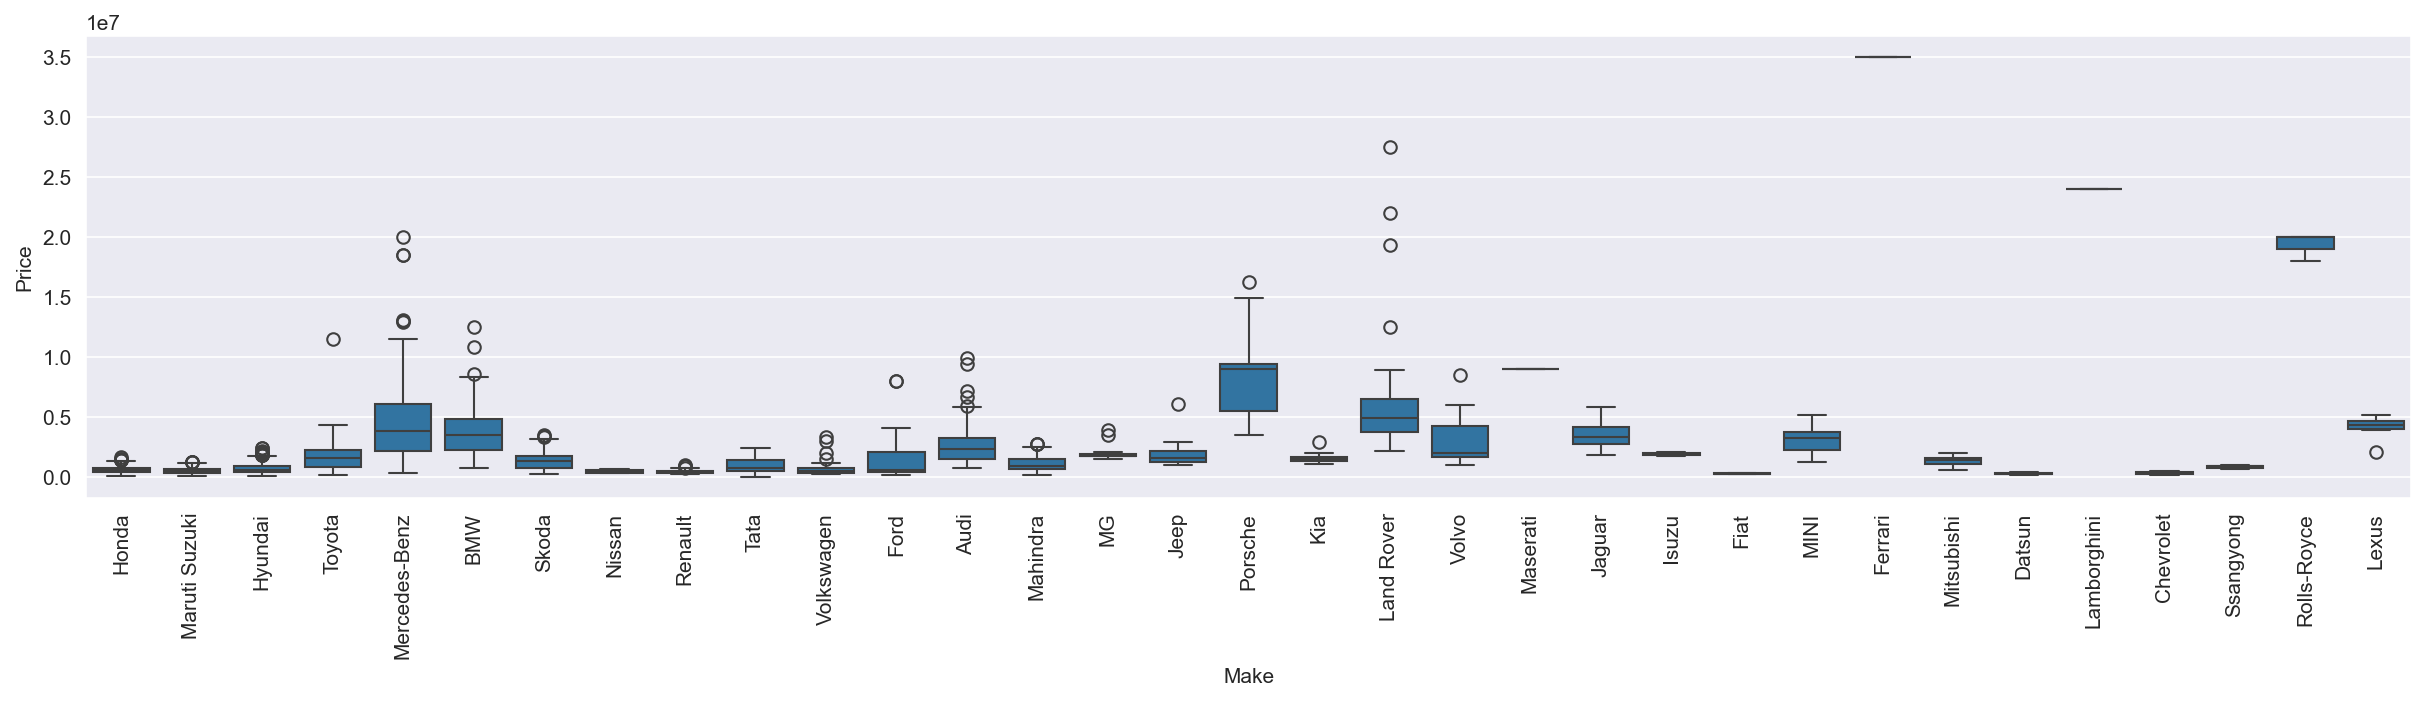

In [90]:
plt.figure(figsize=(20, 4), dpi=150)
sns.boxplot(x='Make', y='Price', data=df)
plt.xticks(rotation=90);

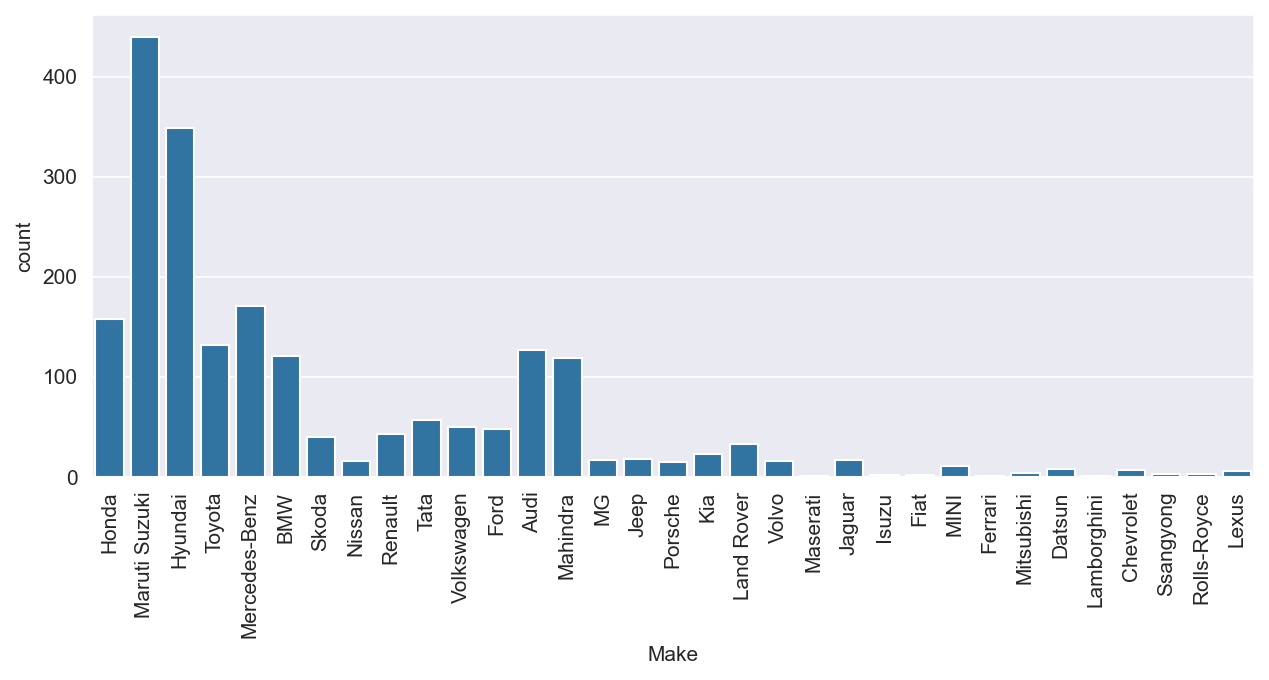

In [91]:
plt.figure(figsize=(10, 4), dpi=150)
sns.countplot(x='Make', data=df)
plt.xticks(rotation=90);

---
## Correlation Analysis

In [92]:
df_corr = df.corr(numeric_only=True)

<Axes: >

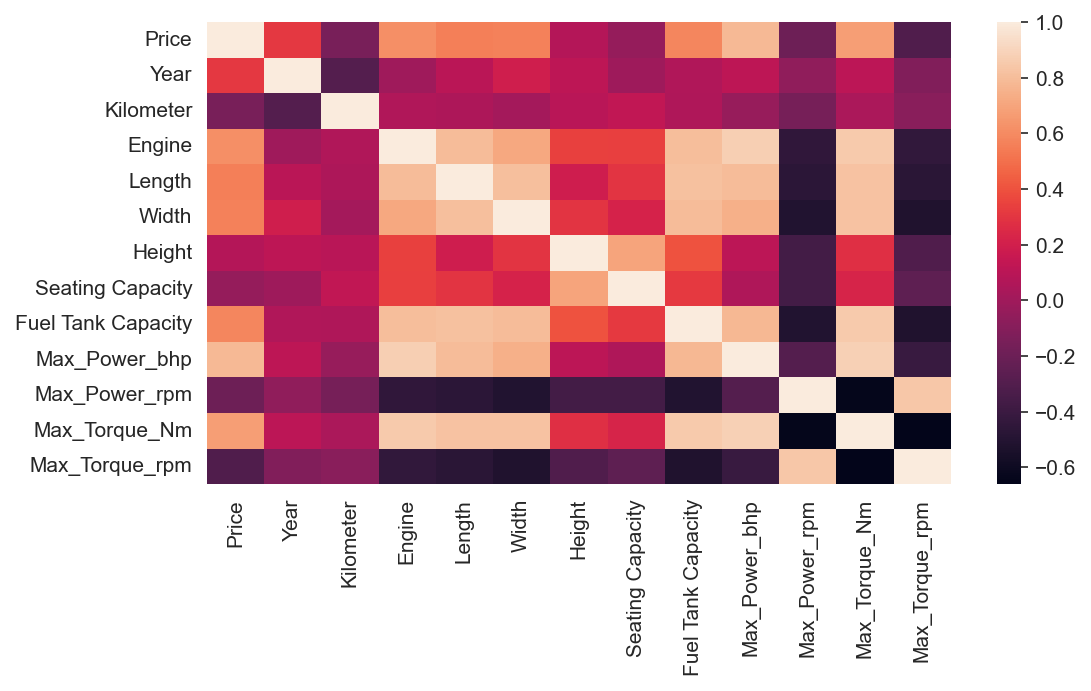

In [93]:
plt.figure(figsize=(8, 4), dpi=150)
sns.heatmap(df_corr)

In [94]:
df_corr['Price'].sort_values(ascending=False)

Price                 1.000000
Max_Power_bhp         0.781287
Max_Torque_Nm         0.671290
Engine                0.615328
Fuel Tank Capacity    0.584631
Width                 0.563996
Length                0.556741
Year                  0.311400
Height                0.075080
Seating Capacity     -0.038524
Kilometer            -0.150825
Max_Power_rpm        -0.197078
Max_Torque_rpm       -0.314132
Name: Price, dtype: float64

---
## Outlier Analysis

In [95]:
def count_outliers(series: pd.Series) -> int:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    return ((series < lower) | (series > upper)).sum()

In [96]:
price_outlier = count_outliers(df['Price'])

In [97]:
price_outlier

np.int64(215)

<Axes: ylabel='Price'>

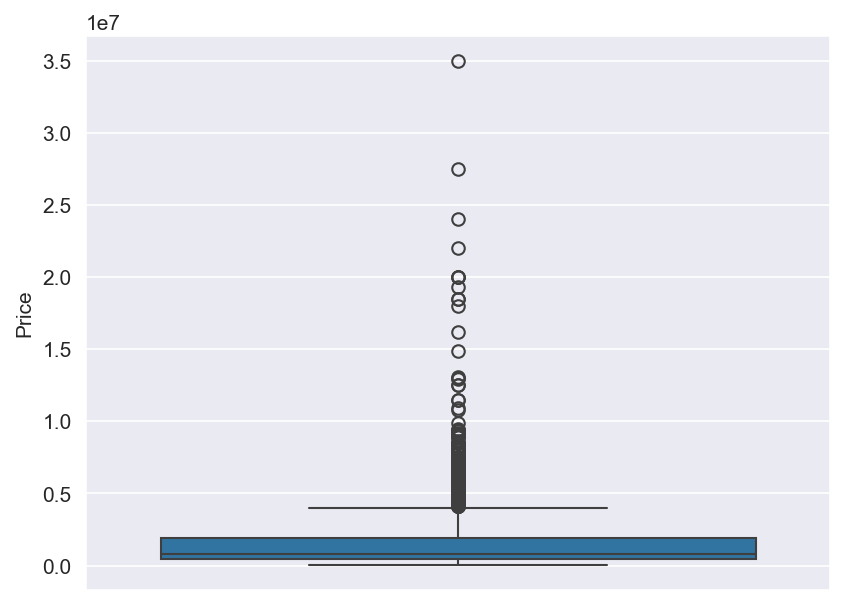

In [98]:
plt.figure(dpi=150)
sns.boxplot(data=df['Price'])

In [99]:
max_power_bph_outlier = count_outliers(df['Max_Power_bhp'])

In [100]:
max_power_bph_outlier

np.int64(31)

<Axes: ylabel='Max_Power_bhp'>

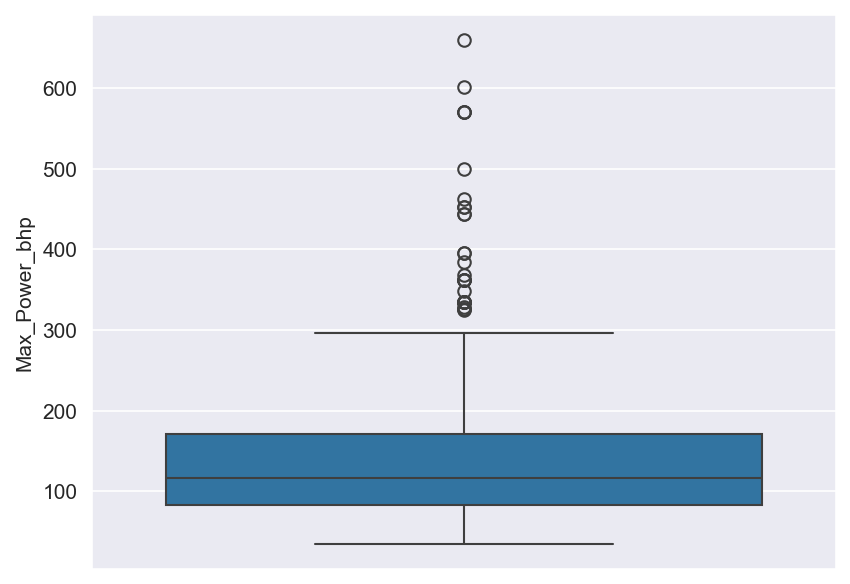

In [101]:
plt.figure(dpi=150)
sns.boxplot(data=df['Max_Power_bhp'])

In [102]:
max_torque_nm_outlier = count_outliers(df['Max_Torque_Nm'])

In [103]:
max_torque_nm_outlier

np.int64(4)

<Axes: ylabel='Max_Torque_Nm'>

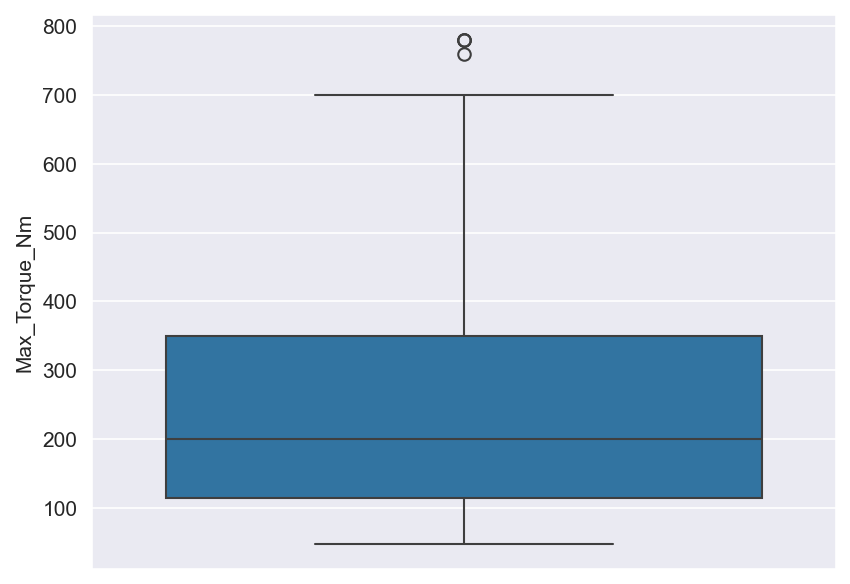

In [104]:
plt.figure(dpi=150)
sns.boxplot(data=df['Max_Torque_Nm'])

In [105]:
engine_outlier = count_outliers(df['Engine'])

In [106]:
engine_outlier

np.int64(25)

<Axes: ylabel='Engine'>

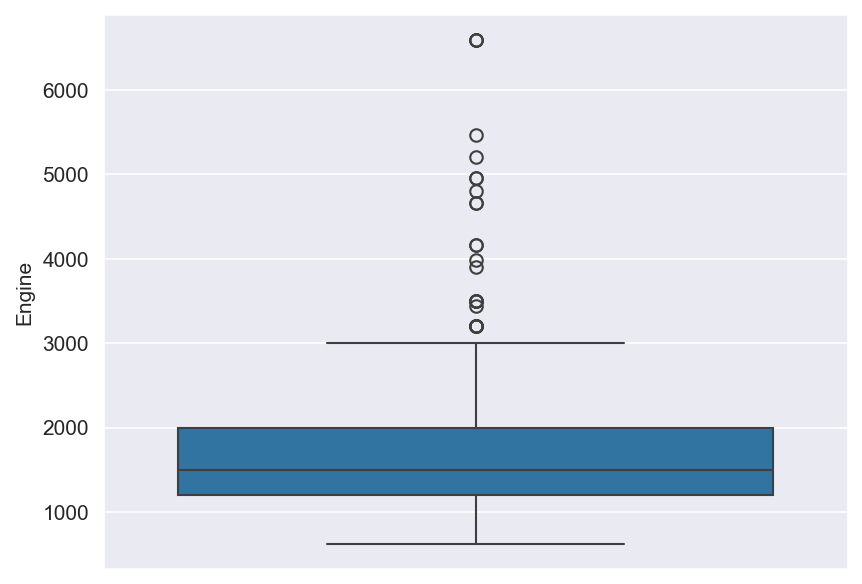

In [107]:
plt.figure(dpi=150)
sns.boxplot(data=df['Engine'])

**Several extreme values were observed in Price, Engine and Power. These values appear to represent luxury and high-performance vehicles rather than data-entry errors; therefore they were retained.**

In [108]:
df.to_csv('../data/car_predict_price.csv', index=False)